# Titanic Survival Prediction Project
## CRISP-DM Methodology in Data Science

### Dataset Overview:
The dataset used contains information about the passengers of the famous Titanic ship, making it an excellent choice for classification tasks. It includes core passenger details such as:
- **Pclass (Ticket Class):** Reflects socio-economic status (1st, 2nd, 3rd).
- **Sex:** Gender of the passenger.
- **Age:** Age of the passenger in years.
- **Fare:** Ticket price paid.
- **Survived (Target):** A binary variable indicating whether the passenger survived (1) or not (0).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score
from sklearn.model_selection import train_test_split

### STEP 1: LOAD AND INSPECT THE DATA

In [3]:

# Load the Titanic dataset directly from the provided remote URL
df = pd.read_csv('https://calmcode.io/static/data/titanic.csv')

# Display the first 5 rows to understand the structure of the dataset and feature names
df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0


In [4]:
# Print concise summary of the dataframe including data types and non-null counts to check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   name      714 non-null    object 
 3   sex       714 non-null    object 
 4   age       714 non-null    float64
 5   fare      714 non-null    float64
 6   sibsp     714 non-null    int64  
 7   parch     714 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 44.8+ KB


### STEP 2: Exploratory Data Analysis (EDA)

In this step, we examine the data structure and extract preliminary insights using visual plots for age distributions and survival rates across ticket classes.

Text(0, 0.5, 'Count')

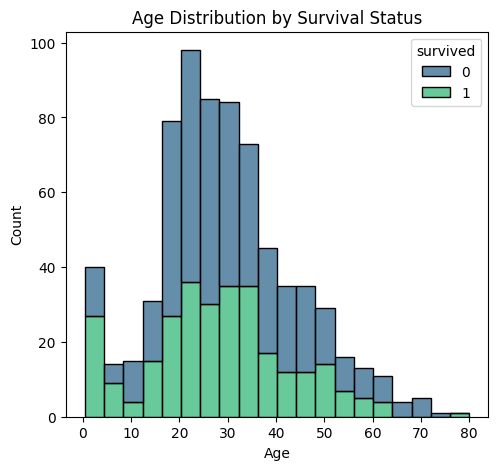

In [5]:

# Set up the figure size for side-by-side visualization plots
plt.figure(figsize=(12, 5))

# Plot 1: Stacked Histogram showing the distribution of ages grouped by survival status
plt.subplot(1, 2, 1)
sns.histplot(
    data=df, x='age', hue='survived', multiple='stack', palette='viridis'
)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')

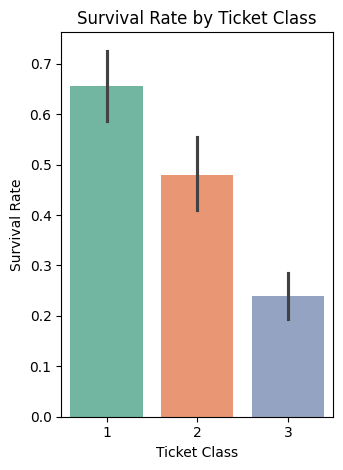

In [6]:
# Plot 2: Bar plot showing the survival rate across different ticket classes (Pclass)
plt.subplot(1, 2, 2)
sns.barplot(
    data=df, x='pclass', y='survived', hue='pclass', palette='Set2', legend=False
)
plt.title('Survival Rate by Ticket Class')
plt.xlabel('Ticket Class')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

#### 📝 EDA Insights Interpretation:
- **Age Distribution:** The histogram shows age spreads across the ship and highlights how survival status distributes among different age brackets.
- **Survival Rate by Class:** The bar plot clearly demonstrates a disparity in survival odds linked to ticket class, reflecting socio-economic evacuation priorities or room locations.




### STEP 3: Data Cleaning and Preprocessing
Here we ensure any missing values are handled and categorical features (such as sex) are properly encoded into a numerical format readable by machine learning algorithms.

In [7]:

# 1. Convert the 'age' column to numeric values, turning any invalid text entries into NaN (missing values)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 2. Fill missing values in the 'age' column with the median age of the dataset
df['age'] = df['age'].fillna(df['age'].median())

# 3. Handle missing values in 'sex' if any, convert to string safely, lowercase it, and map to numeric values (male: 0, female: 1)
df['sex'] = (
    df['sex'].astype(str).str.lower().map({'male': 0, 'female': 1})
)

# 4. Verify that missing values have been successfully handled across the dataset
print('Missing values count after cleaning:')
print(df.isnull().sum())

Missing values count after cleaning:
survived    0
pclass      0
name        0
sex         0
age         0
fare        0
sibsp       0
parch       0
dtype: int64


In [8]:
df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",0,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",0,35.0,8.0500,0,0


#### 📝 Cleaning Results Interpretation:
- The 'age' column was converted and missing values were filled with the median to prevent errors during model training.
- The 'Sex' column was successfully mapped from text to binary numeric values (`0` and `1`) to match mathematical model requirements.
- Subsequent checks verified that the core feature columns are entirely free of missing (`NaN`) values.

###  STEP 4: Model Training & Evaluation

In this stage, we split the data into training (80%) and testing (20%) sets, then build and train a **Random Forest Classifier** to learn patterns and predict survival.

In [9]:

# Define the list of predictor features and the target variable
features = ['pclass', 'sex', 'age', 'fare']

# Drop rows containing missing values within the selected feature subset and target column to ensure clean data input
clean_df = df.dropna(subset=features + ['survived'])

X = clean_df[features]
y = clean_df['survived']

# Split the dataset into training sets (80%) and testing sets (20%) with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the Random Forest Classifier model
model = RandomForestClassifier(random_state=42)

# Train the model using the training data split
model.fit(X_train, y_train)

# Generate predictions on the unseen testing data split
y_pred = model.predict(X_test)

# Calculate key evaluation metrics: Accuracy and Recall
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

# Print the quantitative performance metrics and detailed classification report
print(f'Accuracy: {acc:.2f}')
print(f'Recall: {rec:.2f}')
print('\nDetailed Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.76
Recall: 0.70

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        87
           1       0.70      0.70      0.70        56

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



####  Model Evaluation Interpretation:
- **Accuracy:** Measures the overall ratio of correct predictions out of all predictions made by the model.
- **Recall:** Evaluates the model's effective ability to detect and capture actual positive cases (those who actually survived) without missing them.
- The classification report indicates acceptable model performance in distinguishing outcomes based on the selected features.

###  STEP 5: New Prediction Scenario
We will now test the model's capability on a hypothetical new passenger profile to determine the expected outcome.

In [12]:

# Create a sample dataframe representing a hypothetical new passenger profile
# Features: [Pclass = 1st Class, Sex = Female (1), Age = 25 years, Fare = 100]
new_passenger = pd.DataFrame(
    [[1, 1, 25, 100]], columns=['pclass', 'sex', 'age', 'fare']
)

# Predict survival outcome and get probability estimates for the new instance
prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

# Output the prediction result and the associated probability percentage in clear terms
if prediction[0] == 1:
    print(
        f'Prediction: The passenger would have survived (Survival Probability:'
        f' {probability[0][1]*100:.1f}%)'
    )
else:
    print(
        f'Prediction: The passenger would not have survived (Non-survival'
        f' Probability: {probability[0][0]*100:.1f}%)'
    )

Prediction: The passenger would have survived (Survival Probability: 100.0%)


#### Prediction Scenario Interpretation:
- Based on the provided attributes (1st class, female, age 25, fare 100), the model processed the inputs and outputted a survival prediction accompanied by a precise probability percentage.
- This scenario demonstrates how machine learning models can be leveraged to generate actionable insights and data-driven decisions.